# PCA — Scikit-Learn Pipeline

## Model: Principal Component Analysis (Dimensionality Reduction)
- **Dataset**: Fashion-MNIST — 60,000 train / 10,000 test, 784 features (28×28 flattened), 10 classes
- **Task**: Compress 784 features while retaining maximum variance
- **Framework showcase**: `IncrementalPCA` — batch-based PCA for large datasets that don't fit in memory

## Evaluation Strategy
- **Intrinsic**: Explained variance ratio, reconstruction error (MSE)
- **Extrinsic**: Downstream KNN classifier accuracy at different component counts
- **Component counts**: [10, 25, 50, 100, 150, 200]

## Pipeline
1. Load data + config
2. Fit PCA + scree plot
3. Visualize principal components
4. Reconstruction grid
5. Component sweep (accuracy vs compression)
6. IncrementalPCA showcase
7. Performance benchmarks
8. Save results

In [1]:
import numpy as np
import pickle
import sys
sys.path.append('../..')

from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.neighbors import KNeighborsClassifier
from utils.data_loader import load_processed_data
from utils.visualization import (plot_scree, plot_reconstruction_grid,
                                  plot_pca_components, plot_component_accuracy)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

import os
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "Scikit-Learn"
N_COMPONENTS_LIST = [10, 25, 50, 100, 150, 200]
IMAGE_SHAPE = (28, 28)

# Step 1: Load preprocessed Fashion-MNIST
X_train, X_test, y_train, y_test, meta = load_processed_data('pca')

# Load scaler for reconstruction visualizations
with open('../../data/processed/pca/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("=" * 60)
print(f"PCA Pipeline — {FRAMEWORK}")
print("=" * 60)
print(f"[1/9] Data loaded")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print(f"  Classes: {meta['n_classes']} — {', '.join(meta['class_names'])}")
print(f"  Scaler: mean shape={scaler['mean'].shape}, std shape={scaler['std'].shape}")

PCA Pipeline — Scikit-Learn
[1/9] Data loaded
  Train: (60000, 784), Test: (10000, 784)
  Classes: 10 — T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Bag, Sneaker, Ankle boot
  Scaler: mean shape=(784,), std shape=(784,)


[2/9] Full PCA fitted
  Components: 784
  Top 10 explain: 62.2%
  90% variance at: 137 components
  95% variance at: 256 components


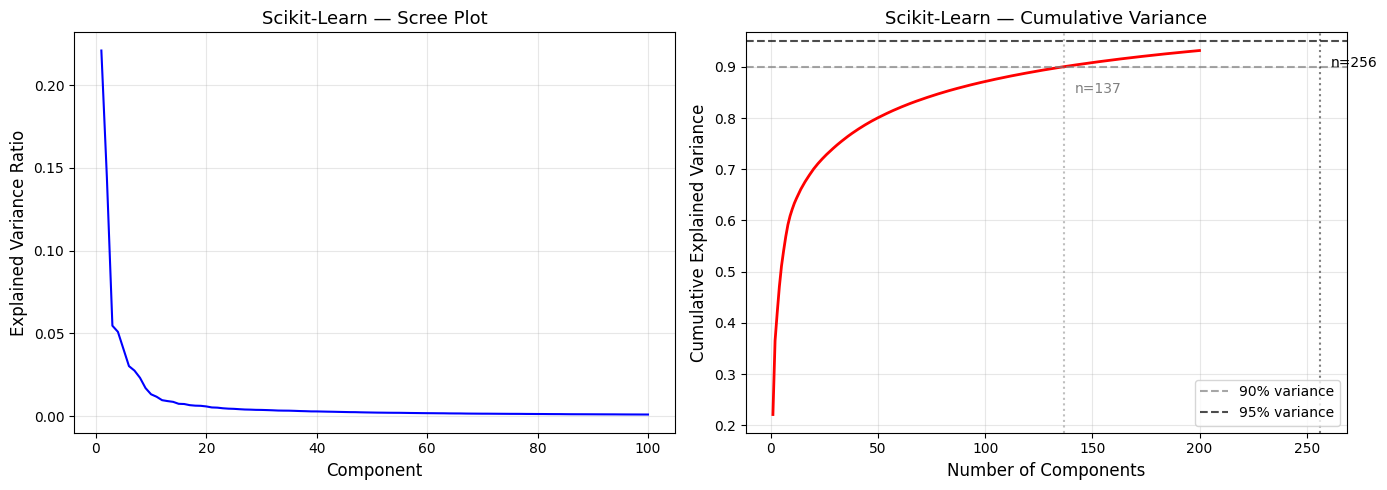

In [2]:
# Step 2: Fit PCA on training data

# Fit with all components first to get full eigenvalue spectrum
# sklearn PCA uses SVD internally — efficient for (n_samples > n_features)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train)

print("=" * 60)
print("[2/9] Full PCA fitted")
print("=" * 60)
print(f"  Components: {pca_full.n_components_}")
print(f"  Top 10 explain: {sum(pca_full.explained_variance_ratio_[:10]):.1%}")
print(f"  90% variance at: {np.searchsorted(np.cumsum(pca_full.explained_variance_ratio_), 0.90) + 1} components")
print(f"  95% variance at: {np.searchsorted(np.cumsum(pca_full.explained_variance_ratio_), 0.95) + 1} components")

# Scree plot
plot_scree(pca_full.explained_variance_ratio_, FRAMEWORK,
           save_path=f'{RESULTS_DIR}/scree_plot.png')

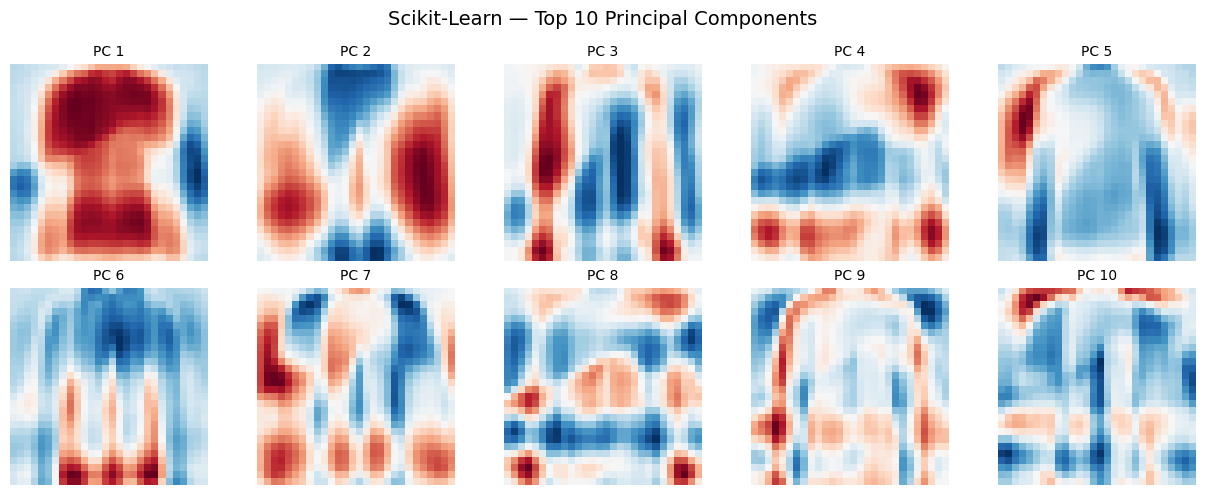

[3/9] Principal components visualized
  PC1 explains: 22.1%
  PC2 explains: 14.4%
  PC10 explains: 1.3%


In [3]:
# Step 3: Visualize top principal components as images

# Each component is a 784-dim vector — reshape to 28x28 to see
# what spatial pattern it captures (edges, textures, shapes)
plot_pca_components(pca_full.components_, IMAGE_SHAPE, n_components=10,
                    framework=FRAMEWORK, save_path=f'{RESULTS_DIR}/principal_components.png')

print("=" * 60)
print("[3/9] Principal components visualized")
print("=" * 60)
print(f"  PC1 explains: {pca_full.explained_variance_ratio_[0]:.1%}")
print(f"  PC2 explains: {pca_full.explained_variance_ratio_[1]:.1%}")
print(f"  PC10 explains: {pca_full.explained_variance_ratio_[9]:.1%}")

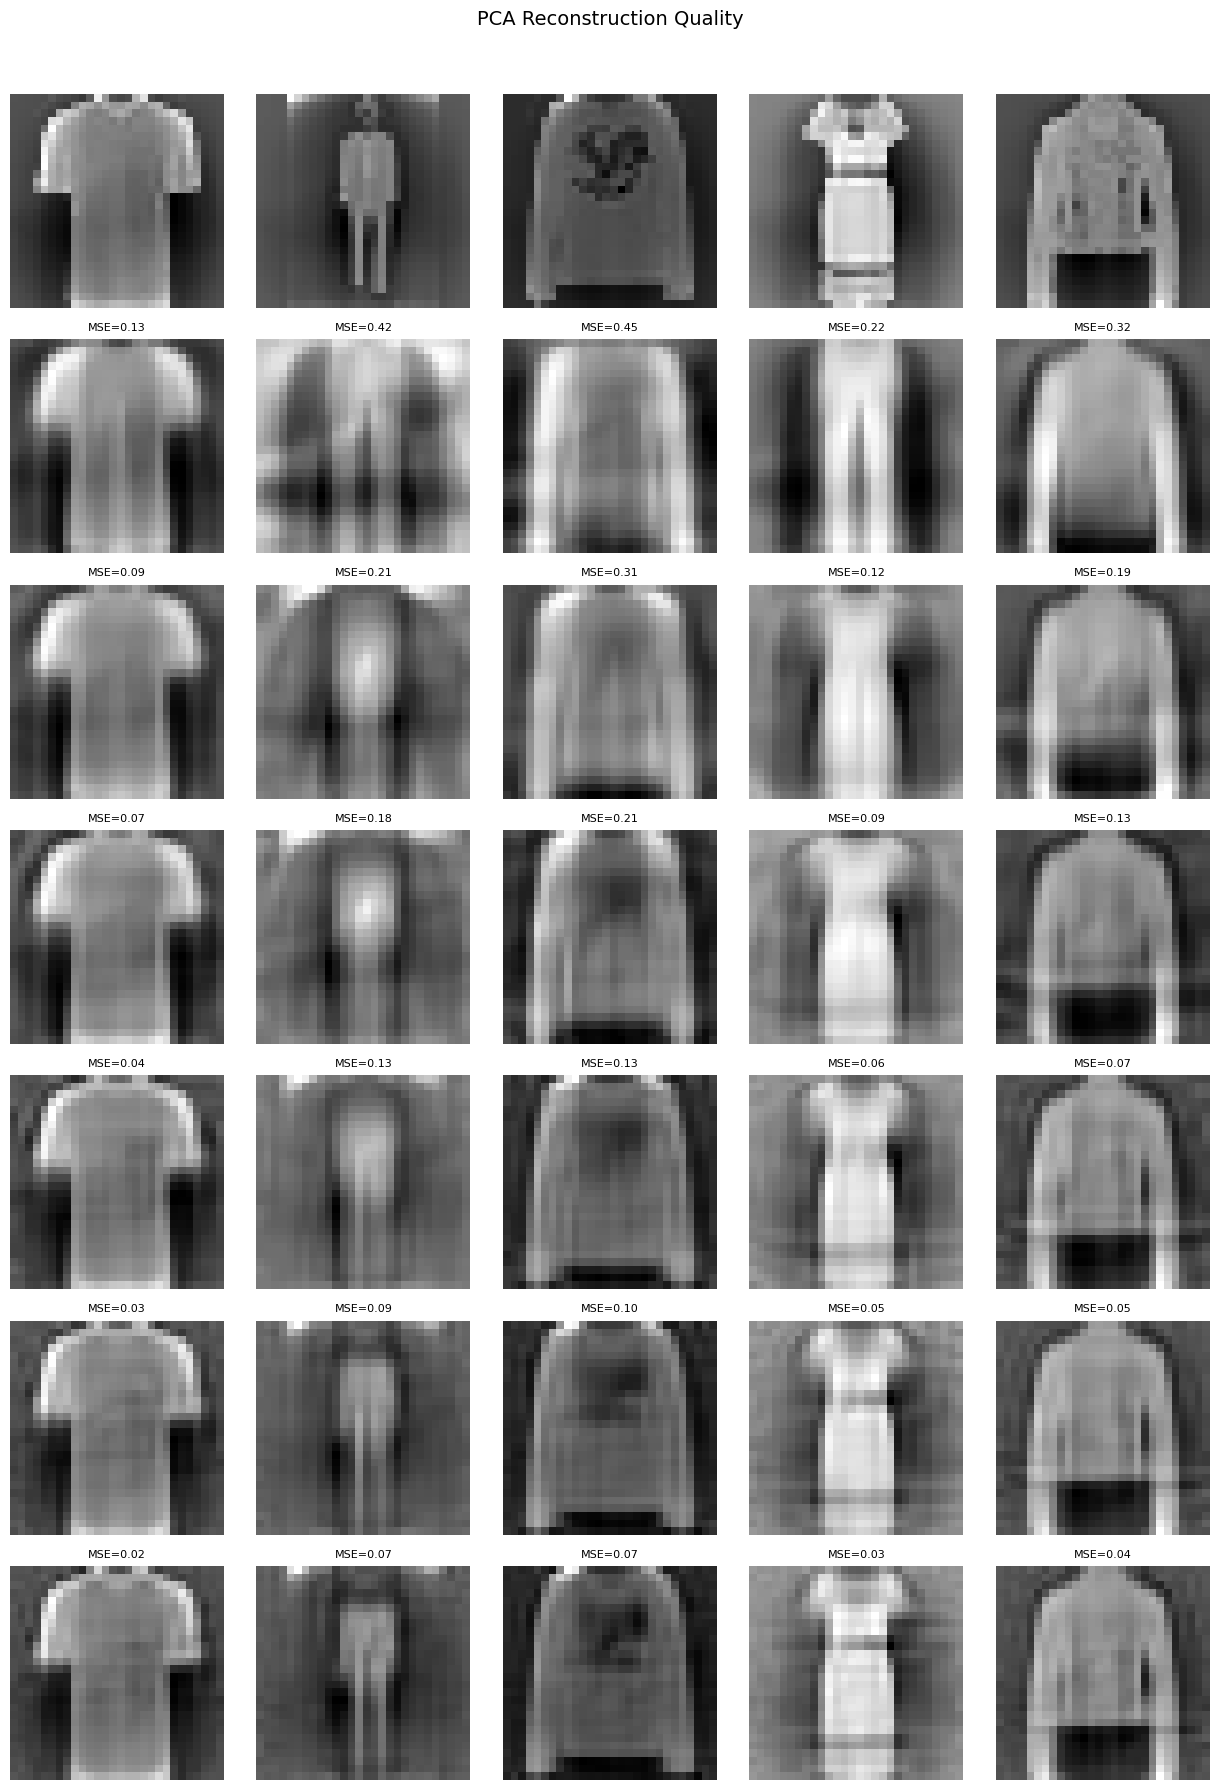

[4/9] Reconstruction quality
  n= 10: MSE=0.3077
  n= 25: MSE=0.1846
  n= 50: MSE=0.1361
  n=100: MSE=0.0886
  n=150: MSE=0.0623
  n=200: MSE=0.0462


In [4]:
# Step 4: Reconstruction at different component counts

from collections import OrderedDict

# Pick 5 diverse test samples (one per class from first 5 classes)
np.random.seed(RANDOM_STATE)
sample_indices = []
for cls in range(5):
    cls_idx = np.where(y_test == cls)[0]
    sample_indices.append(np.random.choice(cls_idx))
originals = X_test[sample_indices]

# Reconstruct at each component count
# reconstruct = X_reduced @ components + mean (sklearn does this via inverse_transform)
reconstructions = OrderedDict()
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    pca_n.fit(X_train)
    X_reduced = pca_n.transform(originals)
    X_recon = pca_n.inverse_transform(X_reduced)
    reconstructions[n_comp] = X_recon

plot_reconstruction_grid(originals, reconstructions, IMAGE_SHAPE, n_samples=5,
                         save_path=f'{RESULTS_DIR}/reconstruction_grid.png')

print("=" * 60)
print("[4/9] Reconstruction quality")
print("=" * 60)
for n_comp, recon in reconstructions.items():
    mse = np.mean((originals - recon) ** 2)
    print(f"  n={n_comp:>3}: MSE={mse:.4f}")

[5/9] Component sweep — KNN accuracy at each n_components
  n= 10: accuracy=0.8014  (784 → 10, 1.3%)
  n= 25: accuracy=0.8385  (784 → 25, 3.2%)
  n= 50: accuracy=0.8506  (784 → 50, 6.4%)
  n=100: accuracy=0.8575  (784 → 100, 12.8%)
  n=150: accuracy=0.8599  (784 → 150, 19.1%)
  n=200: accuracy=0.8598  (784 → 200, 25.5%)


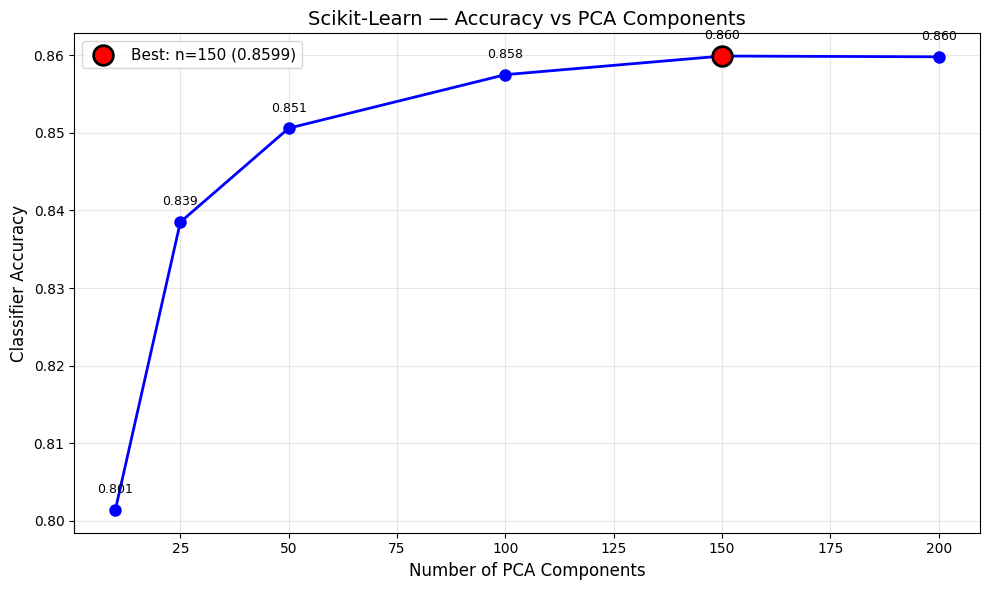

In [5]:
# Step 5: Downstream classifier accuracy vs components

# KNN (K=5) as a simple, consistent downstream classifier
# Same classifier across all 4 frameworks for fair comparison
print("=" * 60)
print("[5/9] Component sweep — KNN accuracy at each n_components")
print("=" * 60)

accuracies = []
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_train_pca = pca_n.fit_transform(X_train)
    X_test_pca = pca_n.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    acc = knn.score(X_test_pca, y_test)
    accuracies.append(acc)
    print(f"  n={n_comp:>3}: accuracy={acc:.4f}  (784 → {n_comp}, {n_comp/784*100:.1f}%)")

plot_component_accuracy(N_COMPONENTS_LIST, accuracies, FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/component_accuracy.png')

In [6]:
# Step 6: IncrementalPCA showcase (SK-exclusive feature)
"""
IncrementalPCA processes data in batches — doesn't need full dataset in memory
Ideal for datasets too large for RAM (Fashion-MNIST fits, but demonstrates the API)
Mathematically equivalent to PCA when all batches are seen
"""
BEST_N = 150
BATCH_SIZE = 5000  # Process 5K samples at a time (12 batches for 60K)

ipca = IncrementalPCA(n_components=BEST_N)

# Fit in batches
n_batches = int(np.ceil(len(X_train) / BATCH_SIZE))
for i in range(n_batches):
    start = i * BATCH_SIZE
    end = min(start + BATCH_SIZE, len(X_train))
    ipca.partial_fit(X_train[start:end])

# Transform and evaluate with same KNN
X_train_ipca = ipca.transform(X_train)
X_test_ipca = ipca.transform(X_test)

knn_ipca = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_ipca.fit(X_train_ipca, y_train)
ipca_acc = knn_ipca.score(X_test_ipca, y_test)

# Compare to standard PCA at same n_components
pca_150 = PCA(n_components=BEST_N, random_state=RANDOM_STATE)
X_train_pca150 = pca_150.fit_transform(X_train)
X_test_pca150 = pca_150.transform(X_test)
knn_pca = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_pca.fit(X_train_pca150, y_train)
pca_acc = knn_pca.score(X_test_pca150, y_test)

print("=" * 60)
print(f"[6/9] IncrementalPCA Showcase (n={BEST_N}, batch_size={BATCH_SIZE})")
print("=" * 60)
print(f"  Standard PCA accuracy:      {pca_acc:.4f}")
print(f"  IncrementalPCA accuracy:    {ipca_acc:.4f}")
print(f"  Difference:                 {abs(pca_acc - ipca_acc):.4f}")
print(f"  Explained variance (IPCA):  {ipca.explained_variance_ratio_.sum():.4f}")
print(f"  Explained variance (PCA):   {pca_150.explained_variance_ratio_.sum():.4f}")
print(f"  Batches processed:          {n_batches}")

[6/9] IncrementalPCA Showcase (n=150, batch_size=5000)
  Standard PCA accuracy:      0.8599
  IncrementalPCA accuracy:    0.8609
  Difference:                 0.0010
  Explained variance (IPCA):  0.9076
  Explained variance (PCA):   0.9085
  Batches processed:          12


In [7]:
# Step 7: Performance Benchmarks

# Training benchmark: fit PCA on training data
pca_bench = PCA(n_components=BEST_N, random_state=RANDOM_STATE)

with track_performance() as perf:
    pca_bench.fit(X_train)

print("=" * 60)
print("[7/9] Performance Benchmarks")
print("=" * 60)
print(f"\n  Training (PCA fit, n={BEST_N}):")
print(f"    Time:        {perf['time']:.4f} s")
print(f"    Memory:      {perf['memory']:.2f} MB")

# Inference benchmark: transform test set
inference_result = track_inference(
    lambda X: pca_bench.transform(X),
    X_test,
    n_runs=100
)

print(f"\n  Inference (transform):")
print(f"    Per sample:  {inference_result['per_sample_us']:.2f} µs")
print(f"    Batch ({X_test.shape[0]:,}): {inference_result['total_time']:.2f} ms")

# Model size
model_size = get_model_size(pca_bench, framework='sklearn')
print(f"\n  Model size:    {model_size / 1024:.2f} KB")
print(f"    Components matrix: {pca_bench.components_.shape}")

[7/9] Performance Benchmarks

  Training (PCA fit, n=150):
    Time:        0.2332 s
    Memory:      11.74 MB

  Inference (transform):
    Per sample:  0.56 µs
    Batch (10,000): 0.01 ms

  Model size:    464.20 KB
    Components matrix: (150, 784)


In [8]:
# Step 8: Save results + cross-framework comparison

# Reconstruction error on test set (using pca_bench from Step 7)
X_test_reduced = pca_bench.transform(X_test)
X_test_recon = pca_bench.inverse_transform(X_test_reduced)
recon_mse = np.mean((X_test - X_test_recon) ** 2)

# PCA intrinsic metrics (replaces evaluate_classifier for unsupervised)
test_metrics = {
    'explained_variance_ratio': pca_bench.explained_variance_ratio_.sum(),
    'reconstruction_mse': recon_mse
}

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='PCA',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_result,
    model_size=model_size,
    n_components=BEST_N,
    downstream_knn_accuracy=float(pca_acc)
)

print("=" * 60)
print("[8/9] Save Results")
print("=" * 60)

# Save locally
save_results(results, save_dir=RESULTS_DIR)

# Add to cross-framework comparison
add_result('pca', results)

# Print comparison (1/4 so far)
print_comparison('pca')

[8/9] Save Results
    Results saved to: results\metrics.json
    Added 'Scikit-Learn' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\pca.json
    Frameworks recorded: 4/4

CROSS-FRAMEWORK COMPARISON: PCA
Metric                          No-Framework       PyTorch    TensorFlow  Scikit-Learn
--------------------------------------------------------------------------------------
model                                    PCA           PCA           PCA           PCA
training_time                         0.23 s        0.11 s        0.17 s        0.23 s
inference_time_per_sample_us         0.89 µs       0.39 µs       0.93 µs       0.56 µs
model_size_bytes                    463.6 KB      463.6 KB      463.6 KB      464.2 KB
peak_memory_mb                     191.18 MB       0.00 MB       0.02 MB      11.74 MB
explained_variance_ratio              0.9085        0.9085        0.9085        0.9085
reconstruction_mse                    0.0951        0.0951    

In [9]:
# Step 9: MLflow Tracking + Model Export (Deployment Prep)

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
import joblib

print("=" * 60)
print("[9/9] MLflow Tracking + Model Export")
print("=" * 60)

# pca_bench already fitted from Step 7 (n=150, best config)

# MLflow experiment logging
mlflow.set_experiment("pca")

with mlflow.start_run(run_name="sklearn-pca-150"):
    # Log hyperparameters
    mlflow.log_params({
        'n_components': BEST_N,
        'svd_solver': 'auto',
        'random_state': RANDOM_STATE,
        'framework': FRAMEWORK,
        'dataset': 'fashion-mnist',
        'n_train_samples': X_train.shape[0],
        'n_features': X_train.shape[1]
    })

    # Log metrics (PCA intrinsic + downstream)
    mlflow.log_metrics({
        'explained_variance_ratio': float(pca_bench.explained_variance_ratio_.sum()),
        'reconstruction_mse': float(recon_mse),
        'downstream_knn_accuracy': float(pca_acc),
        'training_time_s': perf['time'],
        'inference_us_per_sample': inference_result['per_sample_us'],
        'model_size_bytes': model_size,
        'peak_memory_mb': perf['memory']
    })

    # Log model with signature
    # PCA is a transformer — signature uses transform output, not predict
    signature = infer_signature(X_test, pca_bench.transform(X_test))
    mlflow.sklearn.log_model(pca_bench, name="pca-fashion-mnist", signature=signature)

    # Log visualizations as artifacts
    mlflow.log_artifacts("results/", artifact_path="visualizations")

    run_id = mlflow.active_run().info.run_id
    print(f"\n  Run ID:     {run_id}")
    print(f"  Experiment: pca")

# Export model locally for eventual FastAPI serving
joblib.dump(pca_bench, f'{RESULTS_DIR}/pca_model.joblib')
print(f"\n  Model exported: {RESULTS_DIR}/pca_model.joblib")
print(f"  Ready for deployment staging")


[9/9] MLflow Tracking + Model Export


2026/03/16 19:36:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/16 19:36:22 INFO mlflow.store.db.utils: Updating database tables
2026/03/16 19:36:23 INFO mlflow.tracking.fluent: Experiment with name 'pca' does not exist. Creating a new experiment.
2026/03/16 19:36:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/16 19:36:23 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



  Run ID:     378a610e2eed470db16065cf9584634a
  Experiment: pca

  Model exported: results/pca_model.joblib
  Ready for deployment staging
